This notebook has been written for educational purpose and has been realezed according to a Creative Commons CC BY License.

https://creativecommons.org/licenses/by/4.0/

Created by Deborah Grbac for presentation at Università Cattolica del Sacro Cuore di Milano, with Valentina Schiariti, reusing materials from Constellate repository created by JSTOR Labs (ITHAKA) and materials from the Text Analysis Pedagogy Institute organized by JSTOR Labs.

For questions/comments/improvements: write at deborah.grbac@unicatt.it, valentina.schiariti-collaboratore@unicatt.it.
____

# From a txt file available online to a wordcloud

#### In this notebook we will analyse a text file to extract key words and visualize them according to their occurence

Wordcloud are normally used to visualize textual data according to words occurences in text, the bigger is the word in the word cloud, the higher the occurence. An occurence is how many time a word is present in a text.

Remember that to tokenize the text and to draw a word cloud first of all in your terminal you have to install nltk and wordcloud in your terminal.


**Terminal:** `pip install wordcloud` 


**Terminal:** `pip install nltk` 


## We start by tokenize the text, or reducing it to its basic elements, single words, or tokens

## Creating your own basic tokenizer

As explained, the most intuitive way to turn a text into tokens is by  on whitespace and punctuation. It is possible to create your own basic tokenizer by using Python string methods. 

The following example uses the `.split()` method to gather unigrams. We will be using an extract from Shakespeare's Othello, provided at this [link](https://www.folger.edu/explore/shakespeares-works/othello/read/)

In [7]:
import urllib.request
from pathlib import Path

# Step 1: Create a ./data folder if it doesn’t exist
data_folder = Path("./data/")
data_folder.mkdir(exist_ok=True)

# Step 2: Load the text file (in this case we upload the text directly form the Folger Shakespeare library website)
text_address = "https://folger-main-site-assets.s3.amazonaws.com/uploads/2022/11/othello_TXT_FolgerShakespeare.txt"
text_name = './data/' + text_address.rsplit('/', 1)[-1]
urllib.request.urlretrieve(text_address, text_name)

('./data/othello_TXT_FolgerShakespeare.txt',
 <http.client.HTTPMessage at 0x1f4e2fc8048>)

In [8]:
text_path = data_folder / "othello_TXT_FolgerShakespeare.txt"

if text_path.exists():
    print("File loaded successfully!")
else:
    print("File not found. Please download it and place it in the ./data/ folder.")

File loaded successfully!


In [9]:
# Opening a file in read mode
with open(text_path, "r") as f:
    othello_text_extract = f.read(1000) #reading an extract of the text
    print(othello_text_extract)

Othello
by William Shakespeare
Edited by Barbara A. Mowat and Paul Werstine
  with Michael Poston and Rebecca Niles
Folger Shakespeare Library
https://shakespeare.folger.edu/shakespeares-works/othello/
Created on May 11, 2016, from FDT version 0.9.2.1

Characters in the Play
OTHELLO, a Moorish general in the Venetian army
DESDEMONA, a Venetian lady
BRABANTIO, a Venetian senator, father to Desdemona
IAGO, Othello's standard-bearer, or "ancient"
EMILIA, Iago's wife and Desdemona's attendant
CASSIO, Othello's second-in-command, or lieutenant
RODERIGO, a Venetian gentleman
Duke of Venice
Venetian gentlemen, kinsmen to Brabantio:
  LODOVICO
  GRATIANO
Venetian senators
MONTANO, an official in Cyprus
BIANCA, a woman in Cyprus in love with Cassio
Clown, a comic servant to Othello and Desdemona
Gentlemen of Cyprus
Sailors
Servants, Attendants, Officers, Messengers, Herald, Musicians, Torchbearers.


ACT 1
=====

Scene 1
[Enter Roderigo and Iago.]


RODERIGO
Tush,


In [10]:
# See the raw string version of our text
othello_text_extract

'Othello\nby William Shakespeare\nEdited by Barbara A. Mowat and Paul Werstine\n  with Michael Poston and Rebecca Niles\nFolger Shakespeare Library\nhttps://shakespeare.folger.edu/shakespeares-works/othello/\nCreated on May 11, 2016, from FDT version 0.9.2.1\n\nCharacters in the Play\n======================\nOTHELLO, a Moorish general in the Venetian army\nDESDEMONA, a Venetian lady\nBRABANTIO, a Venetian senator, father to Desdemona\nIAGO, Othello\'s standard-bearer, or "ancient"\nEMILIA, Iago\'s wife and Desdemona\'s attendant\nCASSIO, Othello\'s second-in-command, or lieutenant\nRODERIGO, a Venetian gentleman\nDuke of Venice\nVenetian gentlemen, kinsmen to Brabantio:\n  LODOVICO\n  GRATIANO\nVenetian senators\nMONTANO, an official in Cyprus\nBIANCA, a woman in Cyprus in love with Cassio\nClown, a comic servant to Othello and Desdemona\nGentlemen of Cyprus\nSailors\nServants, Attendants, Officers, Messengers, Herald, Musicians, Torchbearers.\n\n\nACT 1\n=====\n\nScene 1\n=======\n[En

In [11]:
# Splitting the text string into a list of strings
extract_tokenized_list =  othello_text_extract.split()
list(extract_tokenized_list)

['Othello',
 'by',
 'William',
 'Shakespeare',
 'Edited',
 'by',
 'Barbara',
 'A.',
 'Mowat',
 'and',
 'Paul',
 'Werstine',
 'with',
 'Michael',
 'Poston',
 'and',
 'Rebecca',
 'Niles',
 'Folger',
 'Shakespeare',
 'Library',
 'https://shakespeare.folger.edu/shakespeares-works/othello/',
 'Created',
 'on',
 'May',
 '11,',
 '2016,',
 'from',
 'FDT',
 'version',
 '0.9.2.1',
 'Characters',
 'in',
 'the',
 'Play',
 '======================',
 'OTHELLO,',
 'a',
 'Moorish',
 'general',
 'in',
 'the',
 'Venetian',
 'army',
 'DESDEMONA,',
 'a',
 'Venetian',
 'lady',
 'BRABANTIO,',
 'a',
 'Venetian',
 'senator,',
 'father',
 'to',
 'Desdemona',
 'IAGO,',
 "Othello's",
 'standard-bearer,',
 'or',
 '"ancient"',
 'EMILIA,',
 "Iago's",
 'wife',
 'and',
 "Desdemona's",
 'attendant',
 'CASSIO,',
 "Othello's",
 'second-in-command,',
 'or',
 'lieutenant',
 'RODERIGO,',
 'a',
 'Venetian',
 'gentleman',
 'Duke',
 'of',
 'Venice',
 'Venetian',
 'gentlemen,',
 'kinsmen',
 'to',
 'Brabantio:',
 'LODOVICO',
 '

In [12]:
# Cleaning up the tokens
unigrams = []

for token in extract_tokenized_list:
    token = token.lower() # lowercase tokens
    token = token.replace('.', '') # remove periods
    token = token.replace('!', '') # remove exclamation points
    token = token.replace('?', '') # remove question marks
    unigrams.append(token)

In [17]:
# Load the NLTK stopwords list
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

# Remove stopwords
unigrams = [unigram for unigram in unigrams if unigram not in stop_words]

In [18]:
# Preview the unigrams
list(unigrams)

['othello',
 'william',
 'shakespeare',
 'edited',
 'barbara',
 'mowat',
 'paul',
 'werstine',
 'michael',
 'poston',
 'rebecca',
 'niles',
 'folger',
 'shakespeare',
 'library',
 'https://shakespearefolgeredu/shakespeares-works/othello/',
 'created',
 'may',
 '11,',
 '2016,',
 'fdt',
 'version',
 '0921',
 'characters',
 'play',
 '======================',
 'othello,',
 'moorish',
 'general',
 'venetian',
 'army',
 'desdemona,',
 'venetian',
 'lady',
 'brabantio,',
 'venetian',
 'senator,',
 'father',
 'desdemona',
 'iago,',
 "othello's",
 'standard-bearer,',
 '"ancient"',
 'emilia,',
 "iago's",
 'wife',
 "desdemona's",
 'attendant',
 'cassio,',
 "othello's",
 'second-in-command,',
 'lieutenant',
 'roderigo,',
 'venetian',
 'gentleman',
 'duke',
 'venice',
 'venetian',
 'gentlemen,',
 'kinsmen',
 'brabantio:',
 'lodovico',
 'gratiano',
 'venetian',
 'senators',
 'montano,',
 'official',
 'cyprus',
 'bianca,',
 'woman',
 'cyprus',
 'love',
 'cassio',
 'clown,',
 'comic',
 'servant',
 'ot

The data has been downloaded into the same directory as this notebook. It will appear in the file explorer to the left in a few seconds. Now you can do some analysis.

In [19]:
# Import Counter()
from collections import Counter

# Create a Counter object called `word_frequency`
word_frequency = Counter(unigrams)

In [20]:
# For making wordclouds
from wordcloud import WordCloud
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import urllib

## Create a Word Cloud to Visualize the Data
A visualization using the WordCloud library in Python. To learn more about customizing a wordcloud, [see the documentation](http://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html). 

In [21]:
### Download cloud image for our word cloud shape ###
# It is not required to have a shape to create a word cloud
download_url = 'https://ithaka-labs.s3.amazonaws.com/static-files/images/tdm/tdmdocs/sample_cloud.png'
urllib.request.urlretrieve(download_url, 'sample_cloud.png')
print('Cloud shape downloaded.')

Cloud shape downloaded.


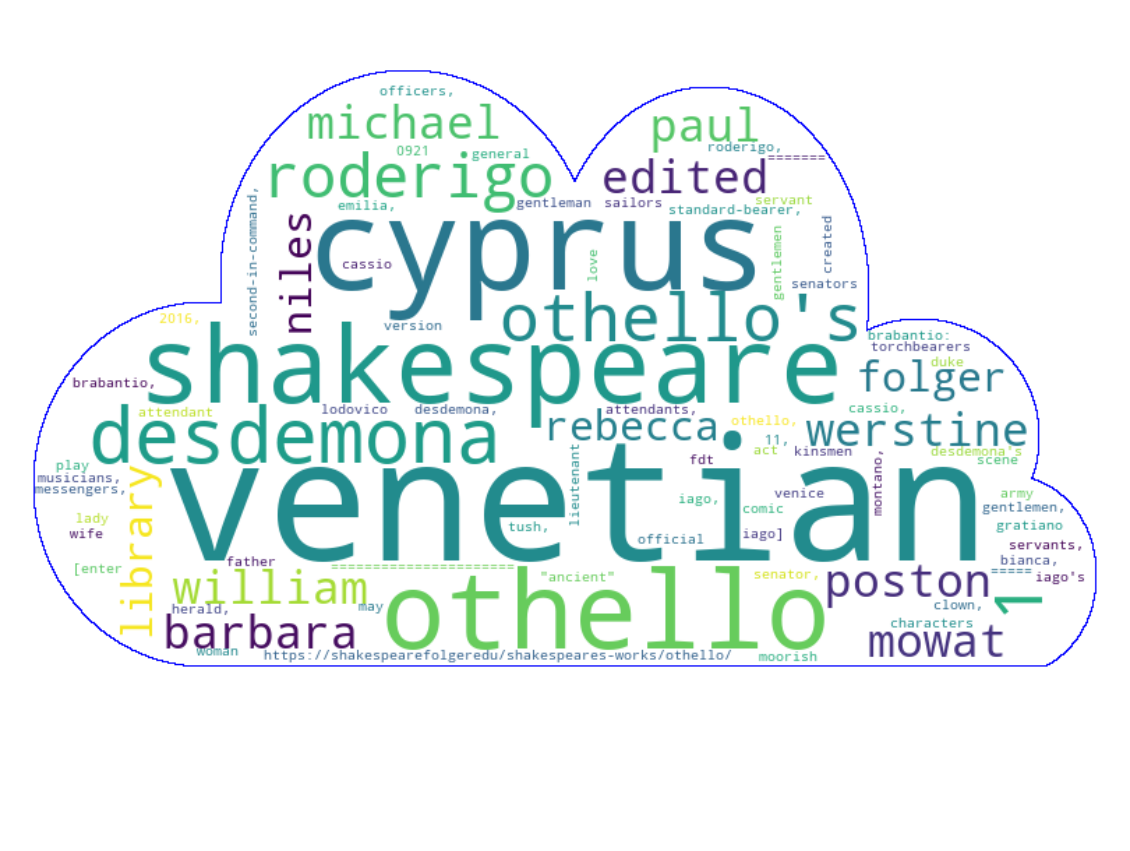

In [22]:
# Create a wordcloud from our data

# Adding a mask shape of a cloud to your word cloud
# By default, the shape will be a rectangle
# You can specify any shape you like based on an image file
cloud_mask = np.array(Image.open('sample_cloud.png')) # Specifies the location of the mask shape
cloud_mask = np.where(cloud_mask > 3, 255, cloud_mask) # this line will take all values greater than 3 and make them 255 (white)

### Specify word cloud details
wordcloud = WordCloud(
    width = 800, # Change the pixel width of the image if blurry
    height = 600, # Change the pixel height of the image if blurry
    background_color = "white", # Change the background color
    colormap = 'viridis', # The colors of the words, see https://matplotlib.org/stable/tutorials/colors/colormaps.html
    max_words = 150, # Change the max number of words shown
    min_font_size = 4, # Do not show small text
    
    # Add a shape and outline (known as a mask) to your wordcloud
    contour_color = 'blue', # The outline color of your mask shape
    mask = cloud_mask, # 
    contour_width = 1
).generate_from_frequencies(word_frequency)

mpl.rcParams['figure.figsize'] = (20,20) # Change the image size displayed
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [28]:
# Print the most common processed unigrams and their counts
for gram, count in word_frequency.most_common(25):
    print(gram.ljust(20), count)

a                    7
venetian             6
and                  5
in                   5
to                   3
cyprus               3
othello              2
by                   2
shakespeare          2
with                 2
the                  2
desdemona            2
othello's            2
or                   2
of                   2
1                    2
roderigo             2
william              1
edited               1
barbara              1
mowat                1
paul                 1
werstine             1
michael              1
poston               1
